In [1]:
from ultralytics import YOLO

# load a model
model = YOLO("yolo11n.pt")  # load an official model
# model = YOLO("path/to/best.pt")  # load a custom model


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/kaarl/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:

# predict with the model
results = model("https://ultralytics.com/images/bus.jpg")  # predict on an image




image 1/1 /home/kaarl/Developer/ai-learning-journey/cv-course/16-ultralytics/bus.jpg: 640x480 4 persons, 1 bus, 41.4ms
Speed: 2.5ms preprocess, 41.4ms inference, 73.7ms postprocess per image at shape (1, 3, 640, 480)


In [3]:
# access the results
for result in results:
    xywh = result.boxes.xywh  # center-x, center-y, width, height
    xywhn = result.boxes.xywhn  # normalized
    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    xyxyn = result.boxes.xyxyn  # normalized
    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    confs = result.boxes.conf  # confidence score of each box

    print(f"xywh: {xywh}")
    print(f"xywhn: {xywhn}")
    print(f"xyxy: {xyxy}")
    print(f"xyxyn: {xyxyn}")
    print(f"target names: {names}")
    print(f"confidences : {confs}")

# save the results
results[0].save("detection_result.jpg")  # saves with bounding boxes drawn
print("Image saved as 'detection_result.jpg'")

xywh: tensor([[400.0188, 478.8901, 792.3900, 499.0579],
        [740.4166, 636.7626, 138.7853, 483.9043],
        [143.3599, 651.8823, 191.8881, 504.6247],
        [283.7649, 634.5628, 121.4022, 451.7558],
        [ 34.4440, 714.2220,  68.8456, 316.2940]], device='cuda:0')
xywhn: tensor([[0.4939, 0.4434, 0.9783, 0.4621],
        [0.9141, 0.5896, 0.1713, 0.4481],
        [0.1770, 0.6036, 0.2369, 0.4672],
        [0.3503, 0.5876, 0.1499, 0.4183],
        [0.0425, 0.6613, 0.0850, 0.2929]], device='cuda:0')
xyxy: tensor([[3.8238e+00, 2.2936e+02, 7.9621e+02, 7.2842e+02],
        [6.7102e+02, 3.9481e+02, 8.0981e+02, 8.7871e+02],
        [4.7416e+01, 3.9957e+02, 2.3930e+02, 9.0419e+02],
        [2.2306e+02, 4.0868e+02, 3.4447e+02, 8.6044e+02],
        [2.1224e-02, 5.5608e+02, 6.8867e+01, 8.7237e+02]], device='cuda:0')
xyxyn: tensor([[4.7208e-03, 2.1237e-01, 9.8298e-01, 6.7446e-01],
        [8.2842e-01, 3.6557e-01, 9.9976e-01, 8.1362e-01],
        [5.8538e-02, 3.6997e-01, 2.9544e-01, 8.3722e-0

In [10]:
unique_names = list(set([result.names[cls.item()] for cls in result.boxes.cls.int()]))
colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan', 'magenta']
color_map = {name: colors[i % len(colors)] for i, name in enumerate(unique_names)}

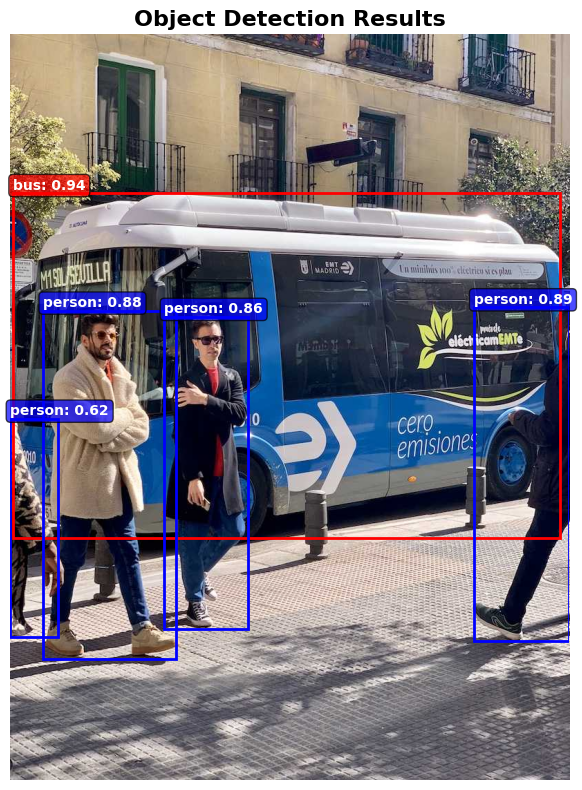

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import requests

# display the original image with bounding boxes
def display_results_with_boxes(results, image_url):
    # get the first result
    result = results[0]
    # load the image
    img = Image.open(requests.get(image_url, stream=True).raw)
    # create figure and axis
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(img)
    # get image dimensions
    img_width, img_height = img.size
    # draw bounding boxes
    

    for i, box in enumerate(result.boxes):
        # get coordinates (xyxy format is most common for drawing)
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf = box.conf[0].cpu().numpy()
        cls = int(box.cls[0].cpu().numpy())
        name = result.names[cls]
        # create rectangle patch
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                               linewidth=2, edgecolor=color_map[name], facecolor='none')
        ax.add_patch(rect)
        # add label with confidence
        ax.text(x1, y1-5, f'{name}: {conf:.2f}', 
               bbox=dict(boxstyle="round,pad=0.3", facecolor=color_map[name], alpha=0.7),
               fontsize=10, color='white', weight='bold')
    
    ax.set_title('Object Detection Results', fontsize=16, weight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# display the results
display_results_with_boxes(results, "https://ultralytics.com/images/bus.jpg")


In [5]:
# alternative: use YOLO's built-in visualization
# this automatically draws bounding boxes and labels
results[0].show()  # show the image with bounding boxes


In [12]:
# save the visualized image
results[0].save("detection_result.jpg")  # saves with bounding boxes drawn
print("Image saved as 'detection_result.jpg'")

# you can also get the annotated image as a numpy array
annotated_img = results[0].plot()  # Returns numpy array with boxes drawn
print(f"Annotated image shape: {annotated_img.shape}")


Image saved as 'detection_result.jpg'
Annotated image shape: (1080, 810, 3)
